In [ ]:
!pip install torch torchvision facenet-pytorch matplotlib seaborn tqdm numpy Pillow roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 77.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-head

In [ ]:
!git clone https://github.com/timesler/facenet-pytorch.git facenet_pytorch

Cloning into 'facenet_pytorch'...
remote: Enumerating objects: 1338, done.
remote: Counting objects: 100% (294/294), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 1338 (delta 237), reused 220 (delta 220), pack-reused 1044 (from 3)
Receiving objects: 100% (1338/1338), 23.19 MiB | 35.13 MiB/s, done.
Resolving deltas: 100% (656/656), done.


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="8HD54Kwr59F84GmFzQZr")
project = rf.workspace("dataseters").project("face-recognition-gesad-7ha7k")
version = project.version(4)
dataset = version.download("folder")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Face-Recognition-GESAD-4 in folder:: 100%|██████████| 4328/4328 [00:01<00:00, 4024.01it/s]


In [ ]:
# SE QUISER OLHAR A PARTE FACE TUNED VÁ PARA A PARTE QUE TEM O FINE TUNING PARA EXECUTAR DE FORMA CORRETA

from facenet_pytorch import MTCNN, InceptionResnetV1
import torch
from PIL import Image
from numpy import asarray
from matplotlib import pyplot
from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import cv2 as cv
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import Normalizer

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Running on device: {}'.format(device))

Running on device: cuda:0


In [ ]:
mtcnn = MTCNN(
    image_size=160, margin=0, min_face_size=20,
    thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True,
    device=device
)

In [ ]:
# CLASS FOR DETECTING FACES
class FACELOADING:
  def __init__(self, directory):
      self.directory = directory
      self.target_size = (160,160)
      self.X = []
      self.Y = []
      self.skipped_images = []
      # Ajuste os parâmetros do MTCNN aqui para tentar detectar mais rostos
      self.mtcnn = MTCNN(
          image_size=160, margin=0, min_face_size=10, # min_face_size reduzido de 20 para 10
          thresholds=[0.5, 0.6, 0.6], factor=0.709, post_process=True, # thresholds reduzidos
          device=device
        )

  def extract_face(self, filename, required_size=(160, 160)):
      img = cv.imread(filename)
      if img is None:
          print(f"Warning: Could not read image {filename}. Skipping.")
          self.skipped_images.append(filename)
          return None
      img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
      # Detect faces
      boxes, _ = self.mtcnn.detect(img)
      if boxes is None or len(boxes) == 0:
          print(f"Warning: No face detected in {filename}. Skipping.")
          self.skipped_images.append(filename)
          return None

      # Apanhar o maior rosto detectado, caso haja múltiplos
      if boxes is not None and len(boxes) > 1:
          areas = [(box[2] - box[0]) * (box[3] - box[1]) for box in boxes]
          largest_box_idx = np.argmax(areas)
          x, y, x2, y2 = boxes[largest_box_idx]
      else:
          x, y, x2, y2 = boxes[0]

      # Converta as coordenadas de float para int
      x, y, x2, y2 = int(x), int(y), int(x2), int(y2)

      # Garanta que as coordenadas estão dentro dos limites da imagem
      x, y = max(0, x), max(0, y)
      x2, y2 = min(x2, img.shape[1]), min(y2, img.shape[0])

      face = img[y:y2, x:x2]
      # Ajuste para garantir que a face não é vazia após o corte
      if face.shape[0] == 0 or face.shape[1] == 0:
          print(f"Warning: Detected face region is empty in {filename}. Skipping.")
          self.skipped_images.append(filename)
          return None

      face_arr = cv.resize(face, self.target_size)
      return face_arr

  def load_faces(self, directory):
    faces = list()
    for filename in os.listdir(directory):
      try:
        path = os.path.join(directory, filename)
        face = self.extract_face(path)
        if face is not None:
          faces.append(face)
      except Exception as e:
        print(f"Error processing {filename}: {e}")
        self.skipped_images.append(filename)

    return faces

  def load_classes(self):
    for subdir in os.listdir(self.directory):
      path = os.path.join(self.directory, subdir)
      if not os.path.isdir(path):
        continue
      faces = self.load_faces(path)
      labels = [subdir for _ in range(len(faces))]
      print(f'Loaded successfully: {len(labels)} faces for class {subdir}')
      self.X.extend(faces)
      self.Y.extend(labels)

    return np.asarray(self.X), np.asarray(self.Y)

In [ ]:
# DETECTING FACES IN EACH CLASS AND CREATING LABEL ENCODER
directory = '/content/Face-Recognition-GESAD-4/train'

faceloading_train = FACELOADING(directory)
X_train_raw, Y_train_raw = faceloading_train.load_classes()

print(f"Loaded {len(X_train_raw)} faces and {len(Y_train_raw)} labels from the training directory.")

Loaded successfully: 104 faces for class David Moreira
Loaded successfully: 3321 faces for class Alan Bandeira
Loaded successfully: 58 faces for class Camila Pinheiro
Loaded 3483 faces and 3483 labels from the training directory.


In [ ]:
directory_valid = '/content/Face-Recognition-GESAD-4/valid'

faceloading_valid = FACELOADING(directory_valid)
X_valid_raw, Y_valid_raw = faceloading_valid.load_classes()

print(f"Loaded {len(X_valid_raw)} faces and {len(Y_valid_raw)} labels from the validation directory.")

Loaded successfully: 10 faces for class David Moreira
Loaded successfully: 369 faces for class Alan Bandeira
Loaded successfully: 6 faces for class Camila Pinheiro
Loaded 385 faces and 385 labels from the validation directory.


In [ ]:
directory_test = '/content/Face-Recognition-GESAD-4/test'

faceloading_test = FACELOADING(directory_test)
X_test_raw, Y_test_raw = faceloading_test.load_classes()

print(f"Loaded {len(X_test_raw)} faces and {len(Y_test_raw)} labels from the test directory.")

Loaded successfully: 5 faces for class David Moreira
Loaded successfully: 370 faces for class Alan Bandeira
Loaded successfully: 2 faces for class Camila Pinheiro
Loaded 377 faces and 377 labels from the test directory.


In [ ]:
encoder = LabelEncoder()

In [ ]:
# INITIALIZING MODEL NOT FACE TUNED AND GETTING EMBEDDINGS
embedder = InceptionResnetV1(pretrained='vggface2').to(device)

def get_embedding(face_img):
  face_img = face_img.astype('float32')
  face_img = np.expand_dims(face_img, axis = 0)

  yhat = embedder.forward(torch.tensor(face_img).permute(0, 3, 1, 2).to(device))
  return yhat[0].detach().cpu().numpy()

  0%|          | 0.00/107M [00:00<?, ?B/s]

In [ ]:
embedded_x = []

embedder.eval()

for img in X_train_raw:
  embedded_x.append(get_embedding(img))

embedded_x = np.asarray(embedded_x)

In [ ]:
Y_train_encoded = encoder.fit_transform(Y_train_raw)

in_encoder = Normalizer(norm='l2')
embedded_x = in_encoder.transform(embedded_x)

In [ ]:
embedded_x_test = []

embedder.eval()

for img in X_test_raw:
  embedded_x_test.append(get_embedding(img))

embedded_x_test = np.asarray(embedded_x_test)

embedded_x_test = in_encoder.transform(embedded_x_test)

Y_test_encoded = encoder.transform(Y_test_raw)

print(f"Extracted and normalized {len(embedded_x_test)} embeddings for the test set.")
print(f"Encoded {len(Y_test_encoded)} labels for the test set.")

Extracted and normalized 377 embeddings for the test set.
Encoded 377 labels for the test set.


In [ ]:
embedded_x_valid = []

embedder.eval()

for img in X_valid_raw:
  embedded_x_valid.append(get_embedding(img))

embedded_x_valid = np.asarray(embedded_x_valid)

embedded_x_valid = in_encoder.transform(embedded_x_valid)

Y_valid_encoded = encoder.transform(Y_valid_raw)

print(f"Extracted and normalized {len(embedded_x_valid)} embeddings for the validation set.")
print(f"Encoded {len(Y_valid_encoded)} labels for the validation set.")

Extracted and normalized 385 embeddings for the validation set.
Encoded 385 labels for the validation set.


In [ ]:
# CREATING BATCHES FOR TRAINING NOT FACE TUNED

from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(embedded_x, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_encoded, dtype=torch.long)
X_valid_tensor = torch.tensor(embedded_x_valid, dtype=torch.float32)
Y_valid_tensor = torch.tensor(Y_valid_encoded, dtype=torch.long)
X_test_tensor = torch.tensor(embedded_x_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_encoded, dtype=torch.long)

batch_size = 32

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, Y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training DataLoader created with {len(train_loader)} batches of size {batch_size}.")
print(f"Validation DataLoader created with {len(valid_loader)} batches of size {batch_size}.")
print(f"Test DataLoader created with {len(test_loader)} batches of size {batch_size}.")

Training DataLoader created with 109 batches of size 32.
Validation DataLoader created with 13 batches of size 32.
Test DataLoader created with 12 batches of size 32.


In [ ]:
import torch.nn as nn

class FaceClassifier(nn.Module):
    def __init__(self, num_classes):
        super(FaceClassifier, self).__init__()
        self.fc1 = nn.Linear(512, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.7)

        self.fc2 = nn.Linear(256, 128) # Segunda camada oculta
        self.bn2 = nn.BatchNorm1d(128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.7)

        self.fc3 = nn.Linear(128, num_classes) # Camada de saída

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

num_classes = len(encoder.classes_)

model = FaceClassifier(num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"FaceClassifier model instantiated with {num_classes} output classes.")
print(f"Model is running on: {device}")
print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam with learning rate 0.001")

FaceClassifier model instantiated with 3 output classes.
Model is running on: cuda:0
Loss function: CrossEntropyLoss
Optimizer: Adam with learning rate 0.001


In [ ]:
# TRAINING NOT FACE TUNED

from sklearn.metrics import accuracy_score

num_epochs = 10

train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    correct_train_predictions = 0
    total_train_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train_samples += labels.size(0)
        correct_train_predictions += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / total_train_samples
    epoch_train_accuracy = correct_train_predictions / total_train_samples
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    model.eval()
    running_valid_loss = 0.0
    correct_valid_predictions = 0
    total_valid_samples = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_valid_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_valid_samples += labels.size(0)
            correct_valid_predictions += (predicted == labels).sum().item()

    epoch_valid_loss = running_valid_loss / total_valid_samples
    epoch_valid_accuracy = correct_valid_predictions / total_valid_samples
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_accuracy)

    print(f'Epoch {epoch+1}/{num_epochs} - ' \
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | ' \
          f'Valid Loss: {epoch_valid_loss:.4f}, Valid Acc: {epoch_valid_accuracy:.4f}')

print('\nTraining complete!')

Epoch 1/10 - Train Loss: 0.3145, Train Acc: 0.9107 | Valid Loss: 0.0923, Valid Acc: 0.9844
Epoch 2/10 - Train Loss: 0.0959, Train Acc: 0.9704 | Valid Loss: 0.0496, Valid Acc: 0.9844
Epoch 3/10 - Train Loss: 0.0718, Train Acc: 0.9770 | Valid Loss: 0.0284, Valid Acc: 0.9922
Epoch 4/10 - Train Loss: 0.0631, Train Acc: 0.9822 | Valid Loss: 0.0265, Valid Acc: 0.9922
Epoch 5/10 - Train Loss: 0.0492, Train Acc: 0.9825 | Valid Loss: 0.0191, Valid Acc: 0.9922
Epoch 6/10 - Train Loss: 0.0497, Train Acc: 0.9825 | Valid Loss: 0.0159, Valid Acc: 0.9974
Epoch 7/10 - Train Loss: 0.0445, Train Acc: 0.9816 | Valid Loss: 0.0143, Valid Acc: 0.9948
Epoch 8/10 - Train Loss: 0.0394, Train Acc: 0.9851 | Valid Loss: 0.0131, Valid Acc: 0.9974
Epoch 9/10 - Train Loss: 0.0372, Train Acc: 0.9877 | Valid Loss: 0.0130, Valid Acc: 0.9922
Epoch 10/10 - Train Loss: 0.0299, Train Acc: 0.9908 | Valid Loss: 0.0079, Valid Acc: 1.0000

Training complete!


# Evaluation

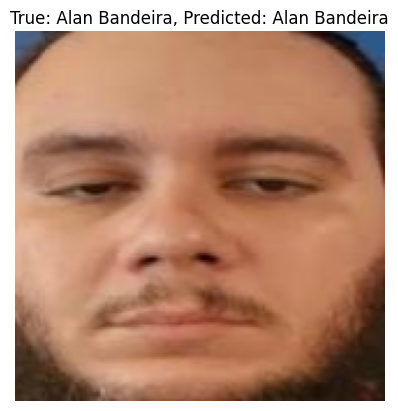

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def visualize_random_prediction(X_raw, Y_encoded, encoder, model, device):
    idx = random.randint(0, len(X_raw) - 1)

    raw_image = X_raw[idx]
    true_label_encoded = Y_encoded[idx]
    true_label_name = encoder.inverse_transform([true_label_encoded])[0]

    sample_embedding = get_embedding(raw_image)

    sample_embedding_tensor = torch.tensor(sample_embedding, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(sample_embedding_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_label_index = torch.argmax(probabilities, dim=1).item()

    predicted_label_name = encoder.inverse_transform([predicted_label_index])[0]

    plt.imshow(raw_image)
    plt.title(f"True: {true_label_name}, Predicted: {predicted_label_name}")
    plt.axis('off')
    plt.show()

visualize_random_prediction(X_test_raw, Y_test_encoded, encoder, model, device)


In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
running_test_loss = 0.0
correct_test_predictions = 0
total_test_samples = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        running_test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_test_samples += labels.size(0)
        correct_test_predictions += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_loss = running_test_loss / total_test_samples
test_accuracy = correct_test_predictions / total_test_samples

print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

f1 = f1_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')

print(f"\nF1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=encoder.classes_))

cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'model' is not defined

In [ ]:
import torch
# funçao que coleta um embedding aleatorio e diz se o modelo acertou ou nao

sample_embedding = embedded_x_test[0]
sample_true_label_encoded = Y_test_encoded[0]

sample_embedding_tensor = torch.tensor(sample_embedding, dtype=torch.float32).unsqueeze(0).to(device)

model.eval()


with torch.no_grad():
    outputs = model(sample_embedding_tensor)


probabilities = torch.softmax(outputs, dim=1)
predicted_label_index = torch.argmax(probabilities, dim=1).item()

predicted_label = encoder.inverse_transform([predicted_label_index])[0]

true_label = encoder.inverse_transform([sample_true_label_encoded])[0]

print(f"Exemplo de embedding:")
print(f"Rótulo real: {true_label}")
print(f"Rótulo previsto: {predicted_label}")
print(f"Previsão correta: {true_label == predicted_label}")

Exemplo de embedding:
Rótulo real: David Moreira
Rótulo previsto: David Moreira
Previsão correta: True


In [ ]:
# FACE TUNING
#To execute the face tuning process, you should execute through cell 1 (import libraries) to cell 8 (creating encoder).
#Then jump to this cell and continue until the end.

import torch.nn as nn
from facenet_pytorch import InceptionResnetV1
from torchvision import transforms

class FineTuneFaceRecognizer(nn.Module):
    def __init__(self, num_classes):
        super(FineTuneFaceRecognizer, self).__init__()
        self.resnet = InceptionResnetV1(pretrained='vggface2')


        self.classifier_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.resnet(x)
        x = self.classifier_head(x)
        return x

num_classes = len(encoder.classes_)
fine_tune_model = FineTuneFaceRecognizer(num_classes).to(device)

criterion_ft = nn.CrossEntropyLoss()
optimizer_ft = torch.optim.AdamW(fine_tune_model.parameters(), lr=0.0001, weight_decay = 0.001)

print(f"FineTuneFaceRecognizer model instantiated with {num_classes} output classes.")
print(f"Model is running on: {device}")
print("Loss function: CrossEntropyLoss")
print("Optimizer: AdamW with learning rate 0.001")

FineTuneFaceRecognizer model instantiated with 3 output classes.
Model is running on: cuda:0
Loss function: CrossEntropyLoss
Optimizer: AdamW with learning rate 0.001


In [ ]:
from torch.utils.data import Dataset, DataLoader

class FaceDataset(Dataset):
    def __init__(self, X_raw, Y_raw):
        self.X_raw = X_raw
        self.Y_raw = Y_raw
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((160, 160)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.X_raw)

    def __getitem__(self, idx):
        image = self.X_raw[idx]
        label = self.Y_raw[idx]

        image = self.transform(image)
        label_encoded = encoder.transform([label])[0]

        return image, torch.tensor(label_encoded, dtype=torch.long)

batch_size = 32
workers = 0 if os.name == 'nt' else 2

train_dataset_ft = FaceDataset(X_train_raw, Y_train_raw)
valid_dataset_ft = FaceDataset(X_valid_raw, Y_valid_raw)
test_dataset_ft = FaceDataset(X_test_raw, Y_test_raw)

train_loader_ft = DataLoader(train_dataset_ft, batch_size=batch_size, shuffle=True, num_workers=workers)
valid_loader_ft = DataLoader(valid_dataset_ft, batch_size=batch_size, shuffle=False, num_workers=workers)
test_loader_ft = DataLoader(test_dataset_ft, batch_size=batch_size, shuffle=False, num_workers=workers)

print(f"Training DataLoader for fine-tuning created with {len(train_loader_ft)} batches of size {batch_size}.")
print(f"Validation DataLoader for fine-tuning created with {len(valid_loader_ft)} batches of size {batch_size}.")
print(f"Test DataLoader for fine-tuning created with {len(test_loader_ft)} batches of size {batch_size}.")

NameError: name 'os' is not defined

In [ ]:
from sklearn.metrics import accuracy_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

num_epochs_ft = 10

train_losses_ft = []
train_accuracies_ft = []
valid_losses_ft = []
valid_accuracies_ft = []

scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.1, patience=2)

max_grad_norm = 1.0

print("Starting Fine-tuning Training...")

for epoch in range(num_epochs_ft):
    fine_tune_model.train()
    running_train_loss_ft = 0.0
    correct_train_predictions_ft = 0
    total_train_samples_ft = 0

    for inputs, labels in train_loader_ft:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_ft.zero_grad()

        outputs = fine_tune_model(inputs)
        loss = criterion_ft(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(fine_tune_model.parameters(), max_norm=max_grad_norm)
        optimizer_ft.step()

        running_train_loss_ft += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train_samples_ft += labels.size(0)
        correct_train_predictions_ft += (predicted == labels).sum().item()

    epoch_train_loss_ft = running_train_loss_ft / total_train_samples_ft
    epoch_train_accuracy_ft = correct_train_predictions_ft / total_train_samples_ft
    train_losses_ft.append(epoch_train_loss_ft)
    train_accuracies_ft.append(epoch_train_accuracy_ft)

    fine_tune_model.eval()
    running_valid_loss_ft = 0.0
    correct_valid_predictions_ft = 0
    total_valid_samples_ft = 0

    with torch.no_grad():
        for inputs, labels in valid_loader_ft:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = fine_tune_model(inputs)
            loss = criterion_ft(outputs, labels)

            running_valid_loss_ft += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_valid_samples_ft += labels.size(0)
            correct_valid_predictions_ft += (predicted == labels).sum().item()

    epoch_valid_loss_ft = running_valid_loss_ft / total_valid_samples_ft
    epoch_valid_accuracy_ft = correct_valid_predictions_ft / total_valid_samples_ft
    valid_losses_ft.append(epoch_valid_loss_ft)
    valid_accuracies_ft.append(epoch_valid_accuracy_ft)

    scheduler_ft.step(epoch_valid_loss_ft)

    print(f'Epoch {epoch+1}/{num_epochs_ft} - ' \
          f'Train Loss: {epoch_train_loss_ft:.4f}, Train Acc: {epoch_train_accuracy_ft:.4f} | ' \
          f'Valid Loss: {epoch_valid_loss_ft:.4f}, Valid Acc: {epoch_valid_accuracy_ft:.4f}')

print('\nFine-tuning Training complete!')

Starting Fine-tuning Training...
Epoch 1/10 - Train Loss: 0.9526, Train Acc: 0.5593 | Valid Loss: 0.7283, Valid Acc: 0.9662
Epoch 2/10 - Train Loss: 0.5571, Train Acc: 0.8091 | Valid Loss: 0.6154, Valid Acc: 0.9844
Epoch 3/10 - Train Loss: 0.3522, Train Acc: 0.9228 | Valid Loss: 0.4304, Valid Acc: 0.9818
Epoch 4/10 - Train Loss: 0.2527, Train Acc: 0.9466 | Valid Loss: 0.2883, Valid Acc: 0.9844
Epoch 5/10 - Train Loss: 0.1969, Train Acc: 0.9552 | Valid Loss: 0.2515, Valid Acc: 0.9844
Epoch 6/10 - Train Loss: 0.1693, Train Acc: 0.9549 | Valid Loss: 0.1756, Valid Acc: 0.9818
Epoch 7/10 - Train Loss: 0.1459, Train Acc: 0.9581 | Valid Loss: 0.1641, Valid Acc: 0.9844
Epoch 8/10 - Train Loss: 0.1240, Train Acc: 0.9566 | Valid Loss: 0.1404, Valid Acc: 0.9844
Epoch 9/10 - Train Loss: 0.1141, Train Acc: 0.9572 | Valid Loss: 0.1193, Valid Acc: 0.9844
Epoch 10/10 - Train Loss: 0.0991, Train Acc: 0.9584 | Valid Loss: 0.1004, Valid Acc: 0.9844

Fine-tuning Training complete!


### Avaliação do Modelo de Fine-tuning no Conjunto de Teste

Test Loss (Fine-tuned Model): 0.0791, Test Accuracy (Fine-tuned Model): 0.9947

F1 Score (Fine-tuned Model): 0.9922
Recall (Fine-tuned Model): 0.9947
Precision (Fine-tuned Model): 0.9898

Classification Report (Fine-tuned Model):
                 precision    recall  f1-score   support

  Alan Bandeira       1.00      1.00      1.00       370
Camila Pinheiro       0.00      0.00      0.00         2
  David Moreira       0.83      1.00      0.91         5

       accuracy                           0.99       377
      macro avg       0.61      0.67      0.64       377
   weighted avg       0.99      0.99      0.99       377



Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


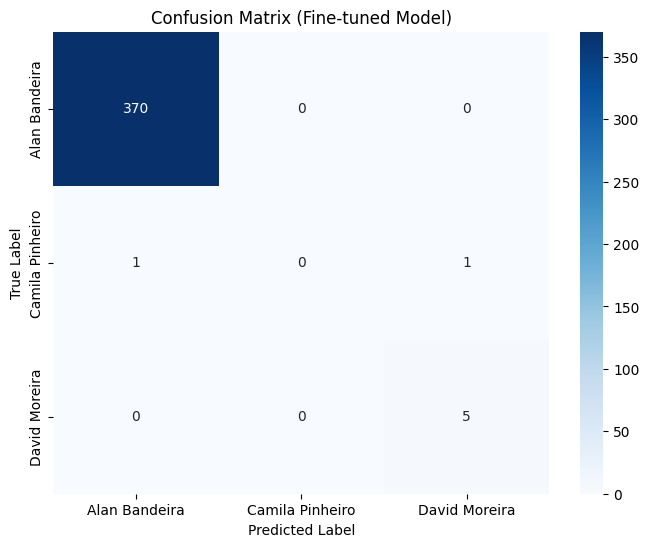

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

fine_tune_model.eval() # Coloca o modelo em modo de avaliação
running_test_loss_ft = 0.0
correct_test_predictions_ft = 0
total_test_samples_ft = 0
all_labels_ft = []
all_predictions_ft = []

with torch.no_grad(): # Desativa o cálculo de gradientes
    for inputs, labels in test_loader_ft:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = fine_tune_model(inputs)
        loss = criterion_ft(outputs, labels)

        running_test_loss_ft += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_test_samples_ft += labels.size(0)
        correct_test_predictions_ft += (predicted == labels).sum().item()

        all_labels_ft.extend(labels.cpu().numpy())
        all_predictions_ft.extend(predicted.cpu().numpy())

test_loss_ft = running_test_loss_ft / total_test_samples_ft
test_accuracy_ft = correct_test_predictions_ft / total_test_samples_ft

print(f'Test Loss (Fine-tuned Model): {test_loss_ft:.4f}, Test Accuracy (Fine-tuned Model): {test_accuracy_ft:.4f}')

f1_ft = f1_score(all_labels_ft, all_predictions_ft, average='weighted')
recall_ft = recall_score(all_labels_ft, all_predictions_ft, average='weighted')
precision_ft = precision_score(all_labels_ft, all_predictions_ft, average='weighted')

print(f"\nF1 Score (Fine-tuned Model): {f1_ft:.4f}")
print(f"Recall (Fine-tuned Model): {recall_ft:.4f}")
print(f"Precision (Fine-tuned Model): {precision_ft:.4f}")

print("\nClassification Report (Fine-tuned Model):")
print(classification_report(all_labels_ft, all_predictions_ft, target_names=encoder.classes_))

cm_ft = confusion_matrix(all_labels_ft, all_predictions_ft)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Fine-tuned Model)')
plt.show()